In [5]:
######     TRAINING THE BASELINE MODEL (LOGISTIC REGRESSION)      ######

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Load your data
train_data = pd.read_csv("../../data/raw/processed_data/train_resampled.csv")
test_data = pd.read_csv("../../data/raw/processed_data/test_data.csv")

# Separate features and target
X_train = train_data.drop("SepsisLabel", axis=1)
y_train = train_data["SepsisLabel"]

X_test = test_data.drop("SepsisLabel", axis=1)
y_test = test_data["SepsisLabel"]

# 🔹 Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional — ROC-AUC (recommended for medical problems)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Accuracy: 0.6888943976202281

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.69      0.81      7482
           1       0.14      0.61      0.22       586

    accuracy                           0.69      8068
   macro avg       0.55      0.65      0.51      8068
weighted avg       0.90      0.69      0.76      8068


Confusion Matrix:
 [[5199 2283]
 [ 227  359]]

ROC-AUC Score: 0.7025058091638361


In [6]:
######     LOGISTIC REGRESSION — ENHANCED HYPERPARAMETER TUNING     ######

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Load your data
train_data = pd.read_csv("../../data/raw/processed_data/train_resampled.csv")
test_data = pd.read_csv("../../data/raw/processed_data/test_data.csv")

# Separate features and target
X_train = train_data.drop("SepsisLabel", axis=1)
y_train = train_data["SepsisLabel"]

X_test = test_data.drop("SepsisLabel", axis=1)
y_test = test_data["SepsisLabel"]

# 🔹 Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------- Define the model --------------------
log_reg = LogisticRegression(max_iter=3000, random_state=42)

# -------------------- Define a richer hyperparameter grid --------------------
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],          # regularization strength
    "penalty": ["l1", "l2", "elasticnet", "none"], # type of regularization
    "solver": ["liblinear", "saga", "lbfgs"],  # optimization algorithms
    "l1_ratio": [0, 0.5, 1]                       # used only when penalty='elasticnet'
}

# -------------------- Stratified Cross Validation --------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------- Grid Search --------------------
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

# -------------------- Best Model --------------------
best_model = grid_search.best_estimator_
print("\n✅ Best Parameters Found:", grid_search.best_params_)

# -------------------- Evaluate Tuned Model --------------------
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\DELL\OneDrive\Documents\ML\venv_n\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DELL\OneDrive\Documents\ML\venv_n\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\DELL\OneDrive\Documents\ML\venv_n\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\OneDrive\Documents\ML\venv_n\Lib\site-pa


✅ Best Parameters Found: {'C': 0.01, 'l1_ratio': 0, 'penalty': 'l2', 'solver': 'liblinear'}

Accuracy: 0.6891422905304908

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.70      0.81      7482
           1       0.14      0.61      0.22       586

    accuracy                           0.69      8068
   macro avg       0.55      0.65      0.51      8068
weighted avg       0.90      0.69      0.76      8068


Confusion Matrix:
 [[5202 2280]
 [ 228  358]]

ROC-AUC Score: 0.7026011460497229


In [1]:
######     LOGISTIC REGRESSION — RANDOMIZED SEARCH CV     ######

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Load your data
train_data = pd.read_csv("../../data/raw/processed_data/train_resampled.csv")
test_data = pd.read_csv("../../data/raw/processed_data/test_data.csv")

# Separate features and target
X_train = train_data.drop("SepsisLabel", axis=1)
y_train = train_data["SepsisLabel"]

X_test = test_data.drop("SepsisLabel", axis=1)
y_test = test_data["SepsisLabel"]

# 🔹 Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------- Define the model --------------------
log_reg = LogisticRegression(max_iter=3000, random_state=42)

# -------------------- Define hyperparameter distributions --------------------
param_dist = {
    "C": np.logspace(-3, 2, 50),                 # Continuous values between 0.001 and 100
    "penalty": ["l1", "l2", "elasticnet", "none"],
    "solver": ["liblinear", "saga", "lbfgs"],
    "l1_ratio": np.linspace(0, 1, 10)            # For elasticnet
}

# -------------------- Stratified Cross Validation --------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------- Randomized Search --------------------
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=30,                # Number of random combinations to try (adjust as needed)
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

# -------------------- Best Model --------------------
best_model = random_search.best_estimator_
print("\n✅ Best Parameters Found:", random_search.best_params_)

# -------------------- Evaluate Tuned Model --------------------
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\DELL\OneDrive\Documents\ML\mlvenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
75 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DELL\OneDrive\Documents\ML\mlvenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\DELL\OneDrive\Documents\ML\mlvenv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\OneDrive\Documents\ML\mlvenv\Lib\site-pack


✅ Best Parameters Found: {'solver': 'lbfgs', 'penalty': 'l2', 'l1_ratio': np.float64(0.0), 'C': np.float64(0.02682695795279726)}

Accuracy: 0.6892662369856222

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.70      0.81      7482
           1       0.14      0.61      0.22       586

    accuracy                           0.69      8068
   macro avg       0.55      0.65      0.51      8068
weighted avg       0.90      0.69      0.76      8068


Confusion Matrix:
 [[5202 2280]
 [ 227  359]]

ROC-AUC Score: 0.7025568987868952


In [8]:
## saving results

import pandas as pd

# Create a small table for your model results
results = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Recall": classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
    "Precision": classification_report(y_test, y_pred, output_dict=True)["1"]["precision"],
    "F1-score": classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"],
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}])

# Save as CSV
results.to_csv("../../results/LR_results.csv", index=False)

print("✅ Results saved to model_results.csv")
results


✅ Results saved to model_results.csv


,Model,Accuracy,Recall,Precision,F1-score,ROC-AUC
0,Logistic Regression,0.689266,0.612628,0.136036,0.222636,0.702557


In [3]:
%pip install dataframe-image

   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------  6.6/6.7 MB 36.6 MB/s eta 0:00:01
   ---------------------------------------- 6.7/6.7 MB 27.2 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 34.1 MB/s  0:00:00
   ---------------------------------------- 0.0/35.5 MB ? eta -:--:--
   ---------------- ----------------------- 14.9/35.5 MB 78.5 MB/s eta 0:00:01
   ----------------------------- ---------- 26.2/35.5 MB 63.9 MB/s eta 0:00:01
   ---------------------------------------  35.4/35.5 MB 62.5 MB/s eta 0:00:01
   ---------------------------------------  35.4/35.5 MB 62.5 MB/s eta 0:00:01
   ---------------------------------------  35.4/35.5 MB 62.5 MB/s eta 0:00:01
   ---------------------------------------- 35.5/35.5 MB 28.5 MB/s  0:00:01

   ----------------------------------------  0/40 [webencodings]
   - -------------------------

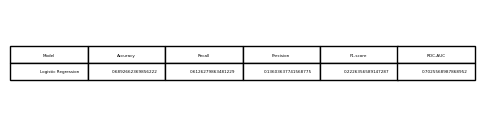

✅ Table image saved using Matplotlib!


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# ensure results is already loaded or created
fig, ax = plt.subplots(figsize=(6, 1 + 0.4 * len(results)))
ax.axis("off")
table = ax.table(cellText=results.values, colLabels=results.columns, loc="center")

plt.savefig("../../results/LR_results_table.png", bbox_inches="tight", dpi=300)
plt.show()

print("✅ Table image saved using Matplotlib!")
